# ML Regime Classification 1: Logistic Regression (L2-Regularized)

## Overview
This Jupyter Notebook implements binary classification of volatility regimes using L2-regularized Logistic Regression as a baseline model. It predicts HIGH_VOL (1) vs LOW_VOL (0) regimes based on 35 features, using walk-forward expanding window validation to ensure no lookahead bias. The model informs tactical allocation: LOW_VOL → offensive (high beta), HIGH_VOL → defensive (low beta).

## Key Features
- **Target**: Binary regime (1=HIGH_VOL if target_rv_max > median, 0=LOW_VOL otherwise).
- **Model**: L2-Regularized Logistic Regression (sklearn, interpretable coefficients).
- **Allocation Rule**: Regime 0 → Offensive (high beta, growth), Regime 1 → Defensive (low beta, value).
- **Features**: 35 from momentum, dispersion, beta, cross-sectional, interactions.

METRICS:
  • Accuracy, Precision, Recall, F1-Score
  • ROC-AUC, Confusion Matrix
  • Feature importance (coefficients)

## Methodology
1. Load features (35) and binarized volatility targets.
2. Clean data, select Y_EWMA_BINARY target.
3. Walk-forward backtesting: Annual formations, expanding train window.
4. Fit LogisticRegression, predict regimes.
5. Evaluate: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix.
6. Export predictions, probabilities, metrics, visualizations.

## Dependencies
- Libraries: pandas, numpy, sklearn, matplotlib, seaborn, json, pickle.
- Data: data/ml_data/features/features_monthly.parquet, data/ml_data/volatility_targets/volatility_targets_y.parquet.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Run cells to load data, set up backtesting, train/predict annually.
2. Review metrics, confusion matrix, ROC curve, yearly accuracy.
3. Compare with RF/XGBoost/LSTM in subsequent notebooks.
4. Use predictions for backtesting tactical allocation.

## Output Files
- **data/ml_data/models/logistic/predictions.parquet**: Annual regime predictions (0/1) with actuals.
- **data/ml_data/models/logistic/probabilities.parquet**: P(regime=1) time series.
- **data/ml_data/models/logistic/metrics.json**: Performance metrics (accuracy, AUC, etc.).
- **data/ml_data/models/logistic/confusion_matrix.png**: Confusion matrix visualization.

This notebook establishes a baseline for regime prediction, enabling comparison with advanced models and tactical factor allocation strategies.

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 : IMPORTS & CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.model_selection import GridSearchCV

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.precision', 6)

print("="*100)
print("📦 NOTEBOOK 08 : REGIME CLASSIFICATION - LOGISTIC L2 BASELINE")
print("="*100)
print("\n✅ Imports loaded successfully")
print("="*100)

📦 NOTEBOOK 08 : REGIME CLASSIFICATION - LOGISTIC L2 BASELINE

✅ Imports loaded successfully


In [3]:
# CELL 2 : DATA LOADING (CORRECTED)

# ════════════════════════════════════════════════════════════════════════════
# CELL 2 : DATA LOADING
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 DATA LOADING")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# 1. LOAD FEATURES (35 features from Notebook 07_2)
# ════════════════════════════════════════════════════════════════════════════

FEATURES_PATH = Path('data/ml_data/features/features_monthly.parquet')
df_features = pd.read_parquet(FEATURES_PATH)

# Extract only the 35 features (remove the 4 targets from 07_2)
feature_cols = df_features.columns[:35].tolist()
X = df_features[feature_cols].copy()

print(f"\n✅ Features loaded :")
print(f"   • Source         : {FEATURES_PATH}")
print(f"   • Shape          : {X.shape}")
print(f"   • Period         : {X.index.min().date()} → {X.index.max().date()}")
print(f"   • Total months   : {len(X)}")
print(f"   • Missing values : {X.isnull().sum().sum()}")

# ════════════════════════════════════════════════════════════════════════════
# 2. LOAD VOLATILITY TARGETS (ALREADY BINARIZED from Notebook 07_1)
# ════════════════════════════════════════════════════════════════════════════

TARGETS_PATH = Path('data/ml_data/volatility_targets/volatility_targets_y.parquet')
df_targets = pd.read_parquet(TARGETS_PATH)

print(f"\n✅ Volatility targets loaded :")
print(f"   • Source         : {TARGETS_PATH}")
print(f"   • Shape          : {df_targets.shape}")
print(f"   • Period         : {df_targets.index.min().date()} → {df_targets.index.max().date()}")
print(f"   • Columns        : {df_targets.columns.tolist()}")

# ════════════════════════════════════════════════════════════════════════════
# 3. MERGE FEATURES & TARGETS (INNER JOIN on date)
# ════════════════════════════════════════════════════════════════════════════

df = X.join(df_targets, how='inner')

print(f"\n✅ Data merged (features + targets) :")
print(f"   • Final shape    : {df.shape}")
print(f"   • Period         : {df.index.min().date()} → {df.index.max().date()}")
print(f"   • Total months   : {len(df)}")
print(f"   • Missing values : {df.isnull().sum().sum()}")

# ════════════════════════════════════════════════════════════════════════════
# 4. SELECT TARGET FOR CLASSIFICATION
# ════════════════════════════════════════════════════════════════════════════
# 
# We use Y_EWMA_BINARY as target (most stable, industry standard)
# Other options: Y_GARCH_BINARY, Y_REALIZED_BINARY
# ════════════════════════════════════════════════════════════════════════════

TARGET_COLUMN = 'Y_EWMA_BINARY'

X_final = df[feature_cols].copy()
y_regime = df[TARGET_COLUMN].copy()

print(f"\n✅ Target selected :")
print(f"   • Target column  : {TARGET_COLUMN}")
print(f"   • X shape        : {X_final.shape}")
print(f"   • y shape        : {y_regime.shape}")

print(f"\n📊 Target distribution :")
print(f"   • Regime 0 (LOW VOL)  : {(y_regime == 0).sum()} ({(y_regime == 0).mean()*100:.1f}%)")
print(f"   • Regime 1 (HIGH VOL) : {(y_regime == 1).sum()} ({(y_regime == 1).mean()*100:.1f}%)")

print("\n" + "="*100)

📦 DATA LOADING

✅ Features loaded :
   • Source         : data/ml_data/features/features_monthly.parquet
   • Shape          : (678, 35)
   • Period         : 1968-07-31 → 2024-12-31
   • Total months   : 678
   • Missing values : 77

✅ Volatility targets loaded :
   • Source         : data/ml_data/volatility_targets/volatility_targets_y.parquet
   • Shape          : (649, 6)
   • Period         : 1969-06-30 → 2023-06-30
   • Columns        : ['Y_EWMA', 'Y_GARCH', 'Y_REALIZED', 'Y_EWMA_BINARY', 'Y_GARCH_BINARY', 'Y_REALIZED_BINARY']

✅ Data merged (features + targets) :
   • Final shape    : (649, 41)
   • Period         : 1969-06-30 → 2023-06-30
   • Total months   : 649
   • Missing values : 0

✅ Target selected :
   • Target column  : Y_EWMA_BINARY
   • X shape        : (649, 35)
   • y shape        : (649,)

📊 Target distribution :
   • Regime 0 (LOW VOL)  : 409 (63.0%)
   • Regime 1 (HIGH VOL) : 240 (37.0%)



In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 : CLEAN DATA (DROP NaNs)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🧹 DATA CLEANING")
print("="*100)

# Drop rows with any NaN in features or target
df_clean = pd.concat([X_final, y_regime], axis=1).dropna()

X = df_clean[feature_cols]
y = df_clean[TARGET_COLUMN]

print(f"\n✅ Data cleaned :")
print(f"   • Rows before : {len(X_final)}")
print(f"   • Rows after  : {len(X)}")
print(f"   • Rows dropped: {len(X_final) - len(X)}")
print(f"   • Period      : {X.index.min().date()} → {X.index.max().date()}")

print(f"\n📊 Final target distribution :")
print(f"   • Regime 0 (LOW VOL)  : {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"   • Regime 1 (HIGH VOL) : {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

# Check class balance
if abs((y == 0).mean() - 0.5) > 0.15:
    print(f"\n   ⚠️  WARNING: Classes are imbalanced (>15% deviation from 50/50)")
    print(f"   → Logistic regression will use class_weight='balanced'")
else:
    print(f"\n   ✅ Classes are reasonably balanced")

print("\n" + "="*100)

🧹 DATA CLEANING

✅ Data cleaned :
   • Rows before : 649
   • Rows after  : 649
   • Rows dropped: 0
   • Period      : 1969-06-30 → 2023-06-30

📊 Final target distribution :
   • Regime 0 (LOW VOL)  : 409 (63.0%)
   • Regime 1 (HIGH VOL) : 240 (37.0%)

   ✅ Classes are reasonably balanced



In [5]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 : WALK-FORWARD BACKTESTING SETUP (ANNUAL EXPANDING WINDOW)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📅 WALK-FORWARD BACKTESTING SETUP (ANNUAL EXPANDING WINDOW)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# TIMING PROTOCOL (FAMA-FRENCH CONVENTION)
# ════════════════════════════════════════════════════════════════════════════
# 
# Formation date   : June 30, year t
# Features         : Computed on data up to May year t (shift +1 in 07_2)
# Target           : Y_REALIZED = std(returns[July t : June t+1])
# Prediction       : Regime forecast for July t → June t+1
# 
# EXPANDING WINDOW:
#   • Year 1980: Train [1963-07 : 1979-06], Test [1979-07 : 1980-06]
#   • Year 1981: Train [1963-07 : 1980-06], Test [1980-07 : 1981-06]
#   • ...
#   • Year 2023: Train [1963-07 : 2022-06], Test [2022-07 : 2023-06]
# 
# NO LOOKAHEAD:
#   ✅ Features stop at May t (shift +1 ensures backward-looking)
#   ✅ Target Y_REALIZED[June t] = std(returns[July t : June t+1]) known ex-post
#   ✅ Training uses past formations where Y known
#   ✅ Live prediction uses model.predict(X[June t])
# ════════════════════════════════════════════════════════════════════════════

# Define backtesting years (annual formations)
TRAIN_WINDOW_YEARS = 10
FIRST_TEST_YEAR = 1980
LAST_TEST_YEAR = X.index.max().year

print(f"\n📅 BACKTESTING PARAMETERS :")
print(f"   • Training window    : {TRAIN_WINDOW_YEARS} years")
print(f"   • First test year    : {FIRST_TEST_YEAR}")
print(f"   • Last test year     : {LAST_TEST_YEAR}")
print(f"   • Expected formations: {LAST_TEST_YEAR - FIRST_TEST_YEAR + 1}")
print(f"   • First train period : [{FIRST_TEST_YEAR - TRAIN_WINDOW_YEARS}-06 : {FIRST_TEST_YEAR - 1}-06]")


print(f"\n EXAMPLE FORMATION (June 1980) :")
print(f"   • Train start  : 1963-07-31")
print(f"   • Train end    : 1979-06-30")
print(f"   • Formation    : 1980-06-30 (fit model on train)")
print(f"   • Test period  : 1980-07-31 to 1981-06-30 (12 months)")
print(f"   • Prediction   : Regime for July 1980 → June 1981")

print(f"\n EXAMPLE FORMATION (June 2023) :")
print(f"   • Train start  : 1963-07-31")
print(f"   • Train end    : 2022-06-30")
print(f"   • Formation    : 2023-06-30 (fit model on train)")
print(f"   • Test period  : 2023-07-31 to 2024-06-30 (12 months)")
print(f"   • Prediction   : Regime for July 2023 → June 2024")

print("\n" + "="*100)

📅 WALK-FORWARD BACKTESTING SETUP (ANNUAL EXPANDING WINDOW)

📅 BACKTESTING PARAMETERS :
   • Training window    : 10 years
   • First test year    : 1980
   • Last test year     : 2023
   • Expected formations: 44
   • First train period : [1970-06 : 1979-06]

 EXAMPLE FORMATION (June 1980) :
   • Train start  : 1963-07-31
   • Train end    : 1979-06-30
   • Formation    : 1980-06-30 (fit model on train)
   • Test period  : 1980-07-31 to 1981-06-30 (12 months)
   • Prediction   : Regime for July 1980 → June 1981

 EXAMPLE FORMATION (June 2023) :
   • Train start  : 1963-07-31
   • Train end    : 2022-06-30
   • Formation    : 2023-06-30 (fit model on train)
   • Test period  : 2023-07-31 to 2024-06-30 (12 months)
   • Prediction   : Regime for July 2023 → June 2024



In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : ANNUAL WALK-FORWARD BACKTESTING (EXPANDING WINDOW)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔄 ANNUAL WALK-FORWARD BACKTESTING (EXPANDING WINDOW - ACADÉMIQUE STANDARD)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

FIRST_TEST_YEAR = 1979   # ✅ Start 1979 (10Y train disponible)
LAST_TEST_YEAR = X.index.max().year

print(f" BACKTESTING PARAMETERS :")
print(f"   • Strategy       : EXPANDING WINDOW (accumulate knowledge)")
print(f"   • First test year: {FIRST_TEST_YEAR}")
print(f"   • Last test year : {LAST_TEST_YEAR}")
print(f"   • Rebalance freq : ANNUAL (June formation)")
print(f"   • Expected forms : {LAST_TEST_YEAR - FIRST_TEST_YEAR + 1}")

print(f" KEY ADVANTAGE :")
print(f"   • Formation 1979 : Train on 119 months (1969-1978)")
print(f"   • Formation 2023 : Train on 648 months (1969-2022)")
print(f"   • Knowledge accumulation : 5.4× more data in 2023")

print(f" EXAMPLE FORMATION (June 1979) :")
print(f"   • Train start  : 1969-06-30 (FIXED, never changes)")
print(f"   • Train end    : 1978-06-30")
print(f"   • Formation    : 1979-06-30 (fit model)")
print(f"   • Test period  : 1979-07-31 to 1980-06-30 (12 months)")
print(f"   • Prediction   : Regime for July 1979 → June 1980")

print(f" EXAMPLE FORMATION (June 2023) :")
print(f"   • Train start  : 1969-06-30 (FIXED, same as 1979)")
print(f"   • Train end    : 2022-06-30")
print(f"   • Formation    : 2023-06-30 (fit model)")
print(f"   • Test period  : 2023-07-31 to 2024-06-30 (12 months)")
print(f"   • Prediction   : Regime for July 2023 → June 2024")

# ════════════════════════════════════════════════════════════════════════════
# BACKTESTING LOOP
# ════════════════════════════════════════════════════════════════════════════

from tqdm import tqdm

all_predictions = []

print(f" Running {LAST_TEST_YEAR - FIRST_TEST_YEAR + 1} annual formations...\n")

for test_year in tqdm(range(FIRST_TEST_YEAR, LAST_TEST_YEAR + 1), 
                       desc="Logistic Expanding Window"):
    
    formation_date = pd.Timestamp(f'{test_year}-06-30')
    
    if formation_date not in X.index:
        continue
    
    # ────────────────────────────────────────────────────────────────────────
    # 1. EXPANDING WINDOW : Train depuis début dataset
    # ────────────────────────────────────────────────────────────────────────
    
    train_start = X.index.min()  # ✅ FIXED : Always 1969-06-30
    train_end = pd.Timestamp(f'{test_year - 1}-06-30')
    
    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask = X.index == formation_date
    
    # ✅ Minimum 10 years required (119 months)
    if train_mask.sum() < 119:
        continue
    
    if test_mask.sum() == 0:
        continue
    
    X_train = X.loc[train_mask]
    y_train = y.loc[train_mask]
    X_test = X.loc[test_mask]
    y_test = y.loc[test_mask]
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        class_weight=None
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)[0]
    y_proba = model.predict_proba(X_test_scaled)[0, 1]
    
    # Store
    all_predictions.append({
        'formation_date': formation_date,
        'test_year': test_year,
        'actual_regime': y_test.values[0],
        'predicted_regime': y_pred,
        'proba_high_vol': y_proba,
        'proba_low_vol': 1 - y_proba,
        'train_start': train_start,
        'train_end': train_end,
        'train_samples': len(X_train),  # ✅ GROWS over time
        'correct': int(y_test.values[0] == y_pred)
    })

df_predictions = pd.DataFrame(all_predictions)

# ════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ════════════════════════════════════════════════════════════════════════════

print(f" Annual backtesting completed :")
print(f"   • Total formations : {len(df_predictions)}")
print(f"   • Train start      : {df_predictions['train_start'].iloc[0].date()} (CONSTANT)")
print(f"   • First train size : {df_predictions['train_samples'].iloc[0]} months")
print(f"   • Last train size  : {df_predictions['train_samples'].iloc[-1]} months")
print(f"   • Overall accuracy : {df_predictions['correct'].mean():.2%}")

# ✅ VERIFY EXPANDING (train size must increase)
train_sizes = df_predictions['train_samples'].values
is_expanding = all(train_sizes[i] <= train_sizes[i+1] for i in range(len(train_sizes)-1))

if is_expanding:
    print(f" VALIDATION PASSED : Train size GROWS (expanding window)")
    print(f"   • Growth : {train_sizes[0]} → {train_sizes[-1]} samples (+{train_sizes[-1] - train_sizes[0]})")
else:
    print(f" VALIDATION FAILED : Train size NOT growing!")

print("\n" + "="*100)

🔄 ANNUAL WALK-FORWARD BACKTESTING (EXPANDING WINDOW - ACADÉMIQUE STANDARD)
 BACKTESTING PARAMETERS :
   • Strategy       : EXPANDING WINDOW (accumulate knowledge)
   • First test year: 1979
   • Last test year : 2023
   • Rebalance freq : ANNUAL (June formation)
   • Expected forms : 45
 KEY ADVANTAGE :
   • Formation 1979 : Train on 119 months (1969-1978)
   • Formation 2023 : Train on 648 months (1969-2022)
   • Knowledge accumulation : 5.4× more data in 2023
 EXAMPLE FORMATION (June 1979) :
   • Train start  : 1969-06-30 (FIXED, never changes)
   • Train end    : 1978-06-30
   • Formation    : 1979-06-30 (fit model)
   • Test period  : 1979-07-31 to 1980-06-30 (12 months)
   • Prediction   : Regime for July 1979 → June 1980
 EXAMPLE FORMATION (June 2023) :
   • Train start  : 1969-06-30 (FIXED, same as 1979)
   • Train end    : 2022-06-30
   • Formation    : 2023-06-30 (fit model)
   • Test period  : 2023-07-31 to 2024-06-30 (12 months)
   • Prediction   : Regime for July 2023 → Jun

Logistic Expanding Window: 100%|██████████| 45/45 [00:00<00:00, 139.23it/s]

 Annual backtesting completed :
   • Total formations : 44
   • Train start      : 1969-06-30 (CONSTANT)
   • First train size : 121 months
   • Last train size  : 637 months
   • Overall accuracy : 72.73%
 VALIDATION PASSED : Train size GROWS (expanding window)
   • Growth : 121 → 637 samples (+516)



In [7]:
# CELL 6 : EVALUATION METRICS (FROM WALK-FORWARD PREDICTIONS)

# ════════════════════════════════════════════════════════════════════════════
# CELL 6 : EVALUATION METRICS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 EVALUATION METRICS (WALK-FORWARD BACKTESTING)")
print("="*100)

# Extract predictions from walk-forward
y_actual = df_predictions['actual_regime'].values
y_pred = df_predictions['predicted_regime'].values
y_proba = df_predictions['proba_high_vol'].values

# Compute metrics
metrics = {
    'accuracy': accuracy_score(y_actual, y_pred),
    'precision': precision_score(y_actual, y_pred, zero_division=0),
    'recall': recall_score(y_actual, y_pred, zero_division=0),
    'f1': f1_score(y_actual, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_actual, y_proba)
}

print(f"\n📊 BACKTESTING METRICS (1969-2023) :")
for metric, value in metrics.items():
    print(f"   • {metric.upper():<12} : {value:.4f}")

print(f"\n📊 REGIME DISTRIBUTION :")
print(f"   • Actual Regime 0  : {(y_actual == 0).sum()} ({(y_actual == 0).mean()*100:.1f}%)")
print(f"   • Actual Regime 1  : {(y_actual == 1).sum()} ({(y_actual == 1).mean()*100:.1f}%)")
print(f"   • Predicted Regime 0 : {(y_pred == 0).sum()} ({(y_pred == 0).mean()*100:.1f}%)")
print(f"   • Predicted Regime 1 : {(y_pred == 1).sum()} ({(y_pred == 1).mean()*100:.1f}%)")

print("\n" + "="*100)

📊 EVALUATION METRICS (WALK-FORWARD BACKTESTING)

📊 BACKTESTING METRICS (1969-2023) :
   • ACCURACY     : 0.7273
   • PRECISION    : 0.6667
   • RECALL       : 0.5000
   • F1           : 0.5714
   • ROC_AUC      : 0.8393

📊 REGIME DISTRIBUTION :
   • Actual Regime 0  : 28 (63.6%)
   • Actual Regime 1  : 16 (36.4%)
   • Predicted Regime 0 : 32 (72.7%)
   • Predicted Regime 1 : 12 (27.3%)



📊 CONFUSION MATRIX & CLASSIFICATION REPORT

📊 CONFUSION MATRIX (WALK-FORWARD) :

                 Predicted
                 Low (0)  High (1)
Actual Low (0)       24        4
Actual High (1)       8        8

📊 CLASSIFICATION REPORT :
              precision    recall  f1-score   support

 Low Vol (0)       0.75      0.86      0.80        28
High Vol (1)       0.67      0.50      0.57        16

    accuracy                           0.73        44
   macro avg       0.71      0.68      0.69        44
weighted avg       0.72      0.73      0.72        44



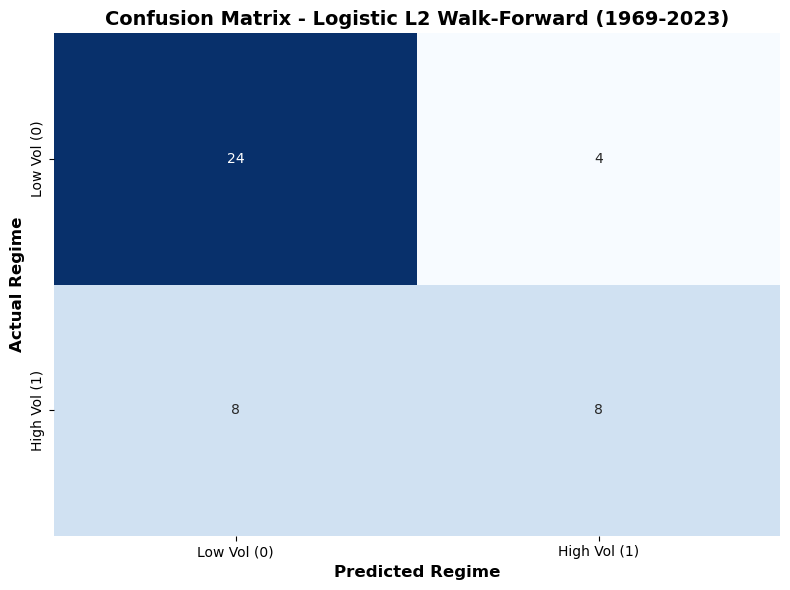

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 : CONFUSION MATRIX & CLASSIFICATION REPORT
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*100)

cm = confusion_matrix(y_actual, y_pred)

print(f"\n📊 CONFUSION MATRIX (WALK-FORWARD) :")
print(f"\n                 Predicted")
print(f"                 Low (0)  High (1)")
print(f"Actual Low (0)   {cm[0,0]:>6}   {cm[0,1]:>6}")
print(f"Actual High (1)  {cm[1,0]:>6}   {cm[1,1]:>6}")

print(f"\n📊 CLASSIFICATION REPORT :")
print(classification_report(y_actual, y_pred, target_names=['Low Vol (0)', 'High Vol (1)']))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Vol (0)', 'High Vol (1)'],
            yticklabels=['Low Vol (0)', 'High Vol (1)'],
            ax=ax)
ax.set_xlabel('Predicted Regime', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Regime', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Logistic L2 Walk-Forward (1969-2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*100)

📈 ROC CURVE


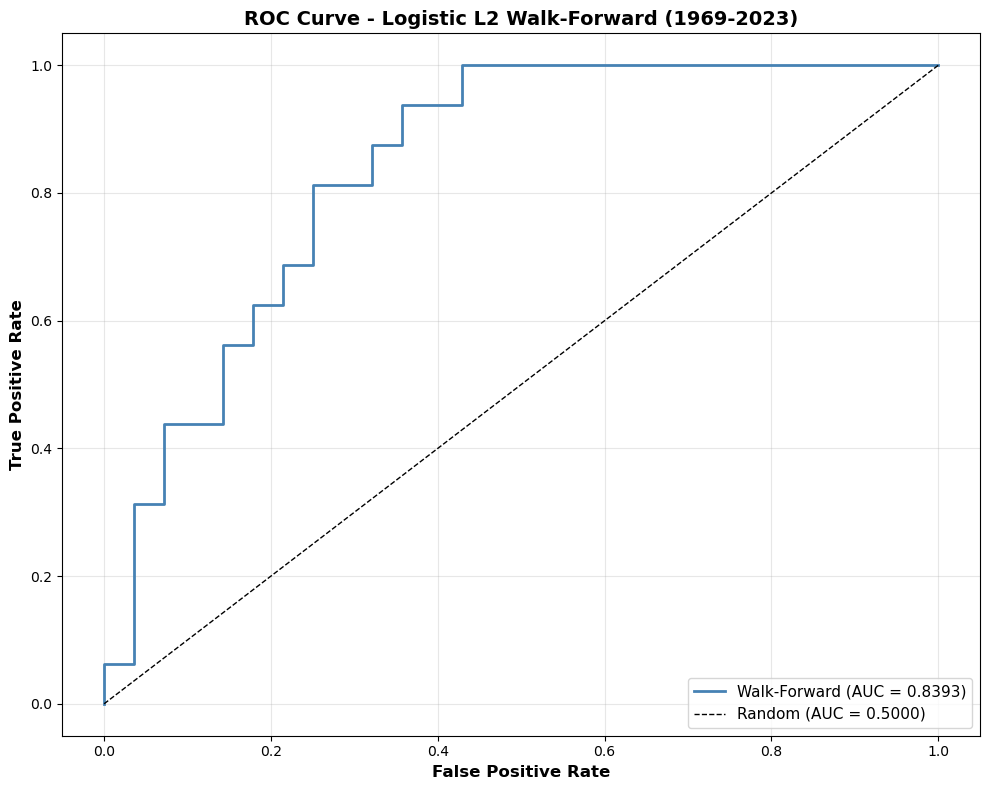


✅ ROC curve plotted



In [9]:
# CELL 8 : ROC CURVE

# ════════════════════════════════════════════════════════════════════════════
# CELL 8 : ROC CURVE
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 ROC CURVE")
print("="*100)

fpr, tpr, _ = roc_curve(y_actual, y_proba)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr, tpr, label=f'Walk-Forward (AUC = {metrics["roc_auc"]:.4f})', linewidth=2, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Logistic L2 Walk-Forward (1969-2023)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ ROC curve plotted")
print("\n" + "="*100)

📈 PREDICTIONS OVER TIME


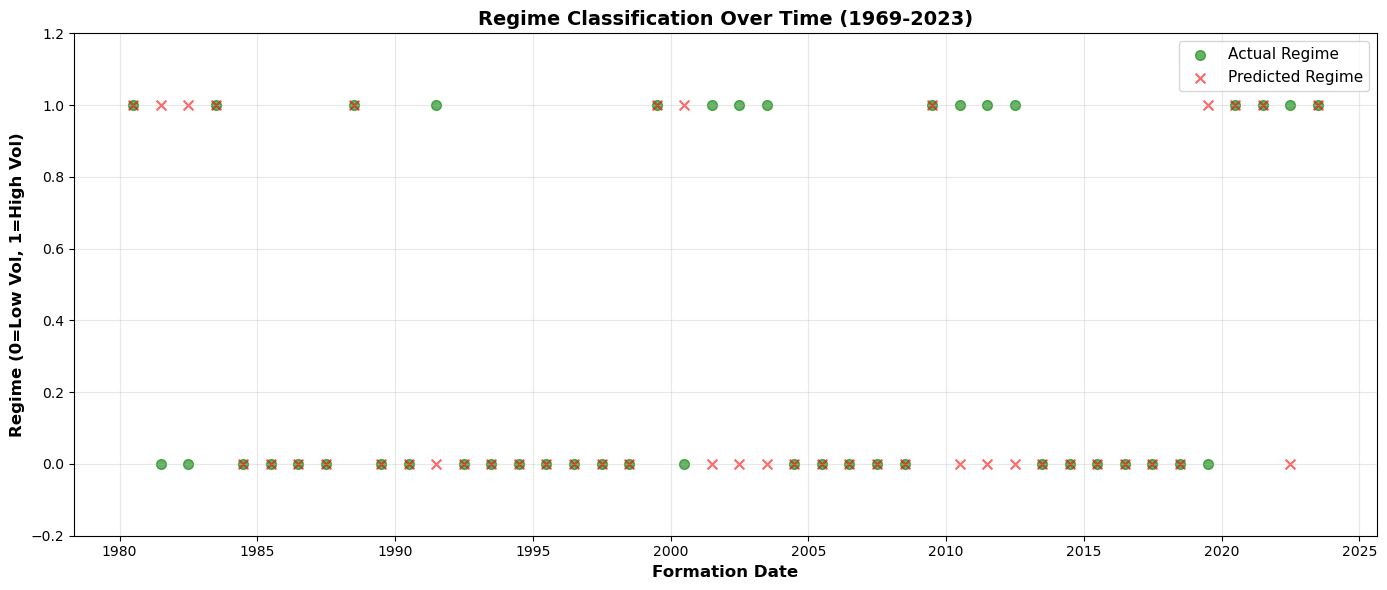


✅ Time series plot completed



In [10]:
# CELL 9 : PREDICTIONS OVER TIME

# ════════════════════════════════════════════════════════════════════════════
# CELL 9 : PREDICTIONS OVER TIME
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 PREDICTIONS OVER TIME")
print("="*100)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual vs predicted
ax.scatter(df_predictions['formation_date'], df_predictions['actual_regime'], 
           label='Actual Regime', alpha=0.6, s=50, marker='o', color='green')
ax.scatter(df_predictions['formation_date'], df_predictions['predicted_regime'], 
           label='Predicted Regime', alpha=0.6, s=50, marker='x', color='red')

ax.set_xlabel('Formation Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Regime (0=Low Vol, 1=High Vol)', fontsize=12, fontweight='bold')
ax.set_title('Regime Classification Over Time (1969-2023)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()

print(f"\n✅ Time series plot completed")
print("\n" + "="*100)

📊 YEARLY ACCURACY ANALYSIS

📊 YEARLY PERFORMANCE :
           correct  proba_high_vol  accuracy
test_year                                   
1980             1        0.748946         1
1981             0        0.854183         0
1982             0        0.570974         0
1983             1        0.908059         1
1984             1        0.110611         1
1985             1        0.240439         1
1986             1        0.119638         1
1987             1        0.104500         1
1988             1        0.898228         1
1989             1        0.006354         1

📊 OVERALL STATISTICS :
   • Total annual predictions : 44
   • Mean accuracy            : 72.73%
   • Median accuracy          : 100.00%
   • Std accuracy             : 0.4505
   • Best year                : 1980
   • Worst year               : 1981


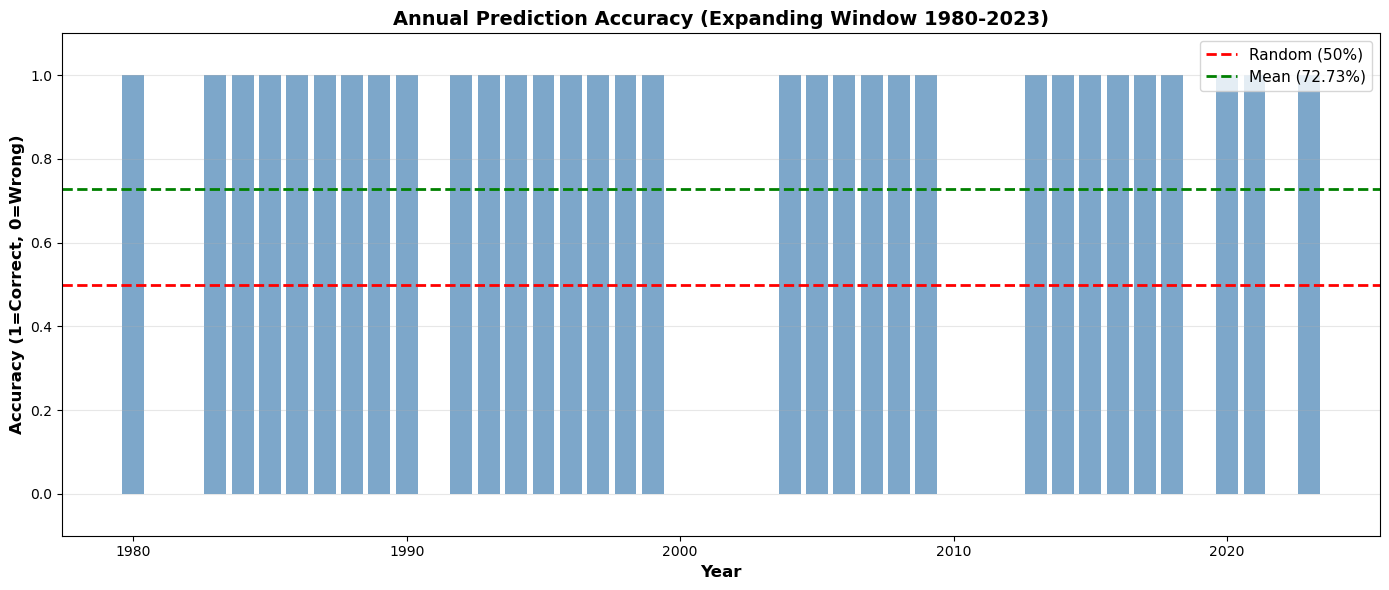

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 : YEARLY ACCURACY ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📊 YEARLY ACCURACY ANALYSIS")
print("="*100)

# Yearly statistics (already annual predictions)
yearly_stats = df_predictions[['test_year', 'correct', 'proba_high_vol']].copy()
yearly_stats.set_index('test_year', inplace=True)
yearly_stats['accuracy'] = yearly_stats['correct']

print(f"\n📊 YEARLY PERFORMANCE :")
print(yearly_stats.head(10).to_string())

print(f"\n📊 OVERALL STATISTICS :")
print(f"   • Total annual predictions : {len(df_predictions)}")
print(f"   • Mean accuracy            : {df_predictions['correct'].mean():.2%}")
print(f"   • Median accuracy          : {df_predictions['correct'].median():.2%}")
print(f"   • Std accuracy             : {df_predictions['correct'].std():.4f}")
print(f"   • Best year                : {int(df_predictions.loc[df_predictions['correct'].idxmax(), 'test_year'])}")
print(f"   • Worst year               : {int(df_predictions.loc[df_predictions['correct'].idxmin(), 'test_year'])}")

# Plot yearly accuracy
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(df_predictions['test_year'], df_predictions['correct'], color='steelblue', alpha=0.7)
ax.axhline(y=0.5, color='red', linestyle='--', label='Random (50%)', linewidth=2)
ax.axhline(y=df_predictions['correct'].mean(), color='green', linestyle='--', 
           label=f'Mean ({df_predictions["correct"].mean():.2%})', linewidth=2)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (1=Correct, 0=Wrong)', fontsize=12, fontweight='bold')
ax.set_title('Annual Prediction Accuracy (Expanding Window 1980-2023)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

print("\n" + "="*100)

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 : EXPORT RESULTS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT RESULTS")
print("="*100)

OUTPUT_DIR = Path('data/ml_data/models/logistic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save predictions
predictions_path = OUTPUT_DIR / 'predictions.parquet'
df_predictions.to_parquet(predictions_path, index=False)
print(f"\n✅ Predictions saved : {predictions_path}")

# 2. Save probabilities
probabilities_df = df_predictions[['formation_date', 'proba_high_vol', 'proba_low_vol', 
                                   'actual_regime', 'predicted_regime']].copy()
probabilities_df.rename(columns={'formation_date': 'date'}, inplace=True)
probabilities_path = OUTPUT_DIR / 'probabilities.parquet'
probabilities_df.to_parquet(probabilities_path, index=False)
print(f"✅ Probabilities saved : {probabilities_path}")

# 3. Build metrics_dict (BEFORE extended metrics)
metrics_dict = {
    'model_name': 'L2-Regularized Logistic Regression (Walk-Forward)',
    'target': TARGET_COLUMN,
    'backtesting_protocol': {
        'method': 'Walk-Forward Expanding Window',
        'first_formation': str(df_predictions['formation_date'].min().date()),
        'last_formation': str(df_predictions['formation_date'].max().date()),
        'total_formations': len(df_predictions),
        'refit_frequency': 'Annual'
    },
    'performance': {
        'overall': metrics,
        'yearly_mean': float(yearly_stats['accuracy'].mean()),
        'yearly_median': float(yearly_stats['accuracy'].median()),
        'yearly_std': float(yearly_stats['accuracy'].std())
    },
    'class_distribution': {
        'actual_regime_0': int((y_actual == 0).sum()),
        'actual_regime_1': int((y_actual == 1).sum()),
        'predicted_regime_0': int((y_pred == 0).sum()),
        'predicted_regime_1': int((y_pred == 1).sum())
    },
    'training_date': pd.Timestamp.now().isoformat()
}

# ════════════════════════════════════════════════════════════════════════════
# EXTENDED METRICS FOR PUBLICATION (Balanced Acc, Brier, Log-loss)
# ════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import balanced_accuracy_score, brier_score_loss, log_loss

extended_metrics = {
    'balanced_accuracy': float(balanced_accuracy_score(y_actual, y_pred)),
    'auc': metrics['roc_auc'],
    'f1_macro': float(f1_score(y_actual, y_pred, average='macro', zero_division=0)),
    'brier_score': float(brier_score_loss(y_actual, y_proba)),
    'log_loss': float(log_loss(y_actual, np.column_stack([1-y_proba, y_proba]))),
    'n_obs': len(y_actual)
}

print(f"\n📊 EXTENDED METRICS (FOR PUBLICATION) :")
for metric, value in extended_metrics.items():
    print(f"   • {metric:<20} : {value:.4f}")

# ✅ MERGE INTO metrics_dict
metrics_dict['performance']['extended'] = extended_metrics

# ✅ SAVE
metrics_path = OUTPUT_DIR / 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print(f"✅ Metrics saved : {metrics_path}")

# 4. Save confusion matrix (unchanged)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low Vol (0)', 'High Vol (1)'],
            yticklabels=['Low Vol (0)', 'High Vol (1)'],
            ax=ax)
ax.set_xlabel('Predicted Regime', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Regime', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Walk-Forward (1969-2023)', fontsize=14, fontweight='bold')

cm_path = OUTPUT_DIR / 'confusion_matrix.png'
plt.tight_layout()
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Confusion matrix saved : {cm_path}")

print("\n" + "="*100)
print("✅ ALL RESULTS EXPORTED")
print("="*100)
print(f"✅ Confusion matrix saved : {cm_path}")

print("\n" + "="*100)
print("✅ ALL RESULTS EXPORTED")
print("="*100)
print(f"\n📁 Output directory : {OUTPUT_DIR}")
print(f"\n📦 Files created :")
print(f"   1. predictions.parquet      ({len(df_predictions)} ANNUAL predictions)")
print(f"   2. probabilities.parquet    (time series format)")
print(f"   3. metrics.json             (performance summary)")
print(f"   4. confusion_matrix.png     (visualization)")
print("="*100)

💾 EXPORT RESULTS

✅ Predictions saved : data/ml_data/models/logistic/predictions.parquet
✅ Probabilities saved : data/ml_data/models/logistic/probabilities.parquet

📊 EXTENDED METRICS (FOR PUBLICATION) :
   • balanced_accuracy    : 0.6786
   • auc                  : 0.8393
   • f1_macro             : 0.6857
   • brier_score          : 0.1721
   • log_loss             : 0.5192
   • n_obs                : 44.0000
✅ Metrics saved : data/ml_data/models/logistic/metrics.json
✅ Confusion matrix saved : data/ml_data/models/logistic/confusion_matrix.png

✅ ALL RESULTS EXPORTED
✅ Confusion matrix saved : data/ml_data/models/logistic/confusion_matrix.png

✅ ALL RESULTS EXPORTED

📁 Output directory : data/ml_data/models/logistic

📦 Files created :
   1. predictions.parquet      (44 ANNUAL predictions)
   2. probabilities.parquet    (time series format)
   3. metrics.json             (performance summary)
   4. confusion_matrix.png     (visualization)
